# Apply Cellpose 2D Model on Image in OMERO

This notebook demonstrates how to apply a Cellpose 2D model on an image stored in a OMERO server.

We start by importing the necessary Python libraries.

In [1]:
import numpy as np
from skimage.io import imshow
from getpass import getpass
import ezomero
from cellpose import models
from omero.constants import metadata

## 1. Connect to OMERO server

In [2]:
HOST = 'omero-int.biotec.tu-dresden.de'

conn = ezomero.connect(host=HOST, user=input("Username: "),
               password=getpass("OMERO Password: "), port=4064, group='', secure=True)

## 2. Opening Image

With OMERO, we need the image ID to open the image.

In [3]:
image_id = 178

We can open the image with `get_image` from `ezomero` and print its shape. Notice now that the shape is standardized to `(T, Z, X, Y, C)`.

In [4]:
omero_image, image = ezomero.get_image(conn, image_id, no_pixels=False)
print(image.shape)

name = omero_image.getName()
print(name)

(1, 1, 254, 256, 1)
blobs


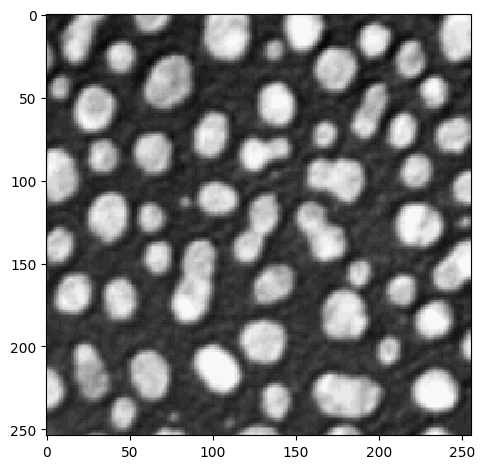

In [5]:
imshow(np.squeeze(image))

It may be useful to also get the dataset ID to save the results.

In [6]:
dataset = omero_image.getParent()
dataset_id = dataset.getId()
print("Dataset ID: ", dataset_id)

Dataset ID:  152


## 3. Loading Pre-trained Model

Cellpose models.

In [7]:
cellpose_model_names = models.MODEL_NAMES
chosen_model = cellpose_model_names[1]
print("Chosen model: ", chosen_model)
model = models.Cellpose(gpu=True, model_type=chosen_model)

Chosen model:  nuclei


## 4. Running Predictions

We run the predictions on the image using the loaded model.

In [8]:
labels, flows, styles, diams = model.eval(image, diameter=15)

Number of Nuclei:  68


c:\Users\mazo260d\mambaforge\envs\omero-cellpose-python\lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:149: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


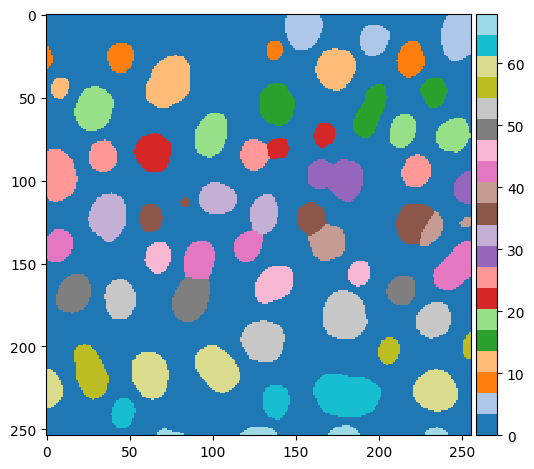

In [9]:
print("Number of Nuclei: ", labels.max())
imshow(labels, cmap='tab20')

## 5. Saving Outputs

Finally, we save the predicted label back to OMERO in the same dataset as the original image.

In [10]:
labels = np.expand_dims(labels, axis=[2, 3, 4])
print(labels.shape)
label_image_name = name + "_label_" + chosen_model
print(label_image_name)

(254, 256, 1, 1, 1)
blobs_label_nuclei


In [13]:
im_id = ezomero.post_image(conn, labels, label_image_name,
                                   dataset_id=dataset_id,
                                   dim_order = 'yxzct') # xyzct led to rotated

## 6. Adding Metadata

In [14]:
ns = metadata.NSCLIENTMAPANNOTATION
dict1 = {'Number of Nuclei': labels.max(),}
ezomero.post_map_annotation(conn, "Image", image_id, dict1, ns)
dict2 = {'Cellpose Model': chosen_model,
         'Number of Nuclei': labels.max(),}
ezomero.post_map_annotation(conn, "Image", im_id, dict2, ns)

object group 3
object group 3


2252

## 7. Closing Connection

In [15]:
conn.close()